In [3]:
import numpy as np
import pandas as pd
import multiprocessing
#import stuff and define functions
from pathlib import Path
import math
from vtk.util import numpy_support
import vtk
import pickle as pk
from tqdm import tqdm

from neutrophil_shape.config.loader import load_config
from neutrophil_shape.CustomFunctions import shtools_mod, shapePCAtools, file_management

In [102]:
### what alignment to use
align = 'trajectory'

### load confocal directory
config = load_config(microscope_type = 'confocal')
config._alignment = align
confocaldir = config.common.savedir / 'shape_data'
## load lls directories
config = load_config(microscope_type = 'lls')
config._alignment = align
datadir = config.common.savedir / 'shape_data'
pcmeshdir = datadir / 'PC_Meshes'



In [ ]:
############# gather data from all experiments ###############
# get the datasets to be combined
datasets = list(datadir.glob('Shape_Metrics*'))
smdf = pd.concat([pd.read_csv(d, index_col=0) for d in datasets], ignore_index = True)


### get all processed data directories
foldlist = [ex.localdir for e, ex in vars(config.experiment).items() if e == 'lls']

#open all of the other metrics from the single csv files
if __name__ == '__main__':
    with multiprocessing.Pool(processes=60) as pool:
        csvlist = [f.joinpath('smooth_traj').glob('*_cell_info.csv') for f in foldlist]
        csvlist = [item for sublist in csvlist for item in sublist]
        celllist = list(tqdm(pool.imap(file_management.multicsv, csvlist), total=len(csvlist)))
cellinfo = pd.concat(celllist, ignore_index = True)

### make dataframes and merge    
combineddata = smdf.merge(cellinfo), on = 'cell', how = 'left')
## drop the bad SH
combineddata = combineddata[combineddata.centroid_inside].copy()

100%|██████████| 10362/10362 [00:17<00:00, 603.22it/s]


In [100]:
########### FILTER THE DATA A BIT ###############
#start by sorting
llsdf = combineddata.copy().sort_values(['CellID','frame']).reset_index(drop=True)
print(len(llsdf))


################ add all of the different classifiers to the dataset
treat = []
experiment = []
date = []

for f, m in zip(llsdf['cell'].to_list(), llsdf['frame'].to_list()):
    if 'CK666' in f:
        treat.append('CK666')
        experiment.append('Drug')
    elif 'ParaNitroBleb' in f:
        treat.append('Para-Nitro-Blebbistatin')
        experiment.append('Drug')
    elif 'DMSO' in f:
        treat.append('DMSO')
        experiment.append('Drug')
    else:
        treat.append('Random')
        experiment.append('Random')
            
    #get the date and experiment number on that date
    spl = f.split('_')
    date.append(spl[0])

llsdf['Date'] = date
llsdf['Treatment'] = treat
llsdf['Experiment'] = experiment



############# filter out shape outliers #############
llsdf = llsdf[llsdf.Cell_Volume > 458]
llsdf = llsdf[llsdf.Cell_SurfaceArea < 1400]
print(len(llsdf), llsdf.Cell_SurfaceArea.sort_values()[-10:].tolist(), llsdf.Cell_Volume.sort_values()[:10].tolist())

############## filter out speed outliers #############
### these seem to come from segmentation failures that move the cell centroid
llsdf = llsdf[(llsdf.speed < 1.3) | (llsdf.speed.isna())]
print(len(llsdf))

############# filter out 20240528 ##############
llsdf = llsdf[~llsdf.cell.str.contains('20240528', na=False)]
print(len(llsdf))

########### filter out all but the cells that I followed for 1hr #########
longcells = [i for i, x in llsdf.groupby('CellID') if len(x)>360]
llsdf = llsdf[llsdf.CellID.isin(longcells)]
#also filter out the one cell I followed that got stuck
llsdf = llsdf[llsdf.CellID != '20240527_488_EGFP-CAAX_640_SPY650-DNA_cell3_01']
print(len(llsdf))

########### filter out cells that touch ############
llsdf = llsdf.sort_values(['CellID','time']).reset_index(drop=True)
touch_ind = llsdf.groupby('image').apply(lambda x:
                              x[(abs(x.Cell_SurfaceArea.pct_change())>0.25)&
                                (x.frame.diff()==1)]).index.tolist()
actual_ind = [x[1] for x in touch_ind]
#drop the first range because this only happens for a brief window with one cell
#and one other small jump
big_jump_frames = [
    ['20240520_488_EGFP-CAAX_561_mysoin-mApple_37C_cell2-06-Subset-01_frame_41',
     '20240520_488_EGFP-CAAX_561_mysoin-mApple_37C_cell2-06-Subset-01_frame_67'],
    ['20240520_488_EGFP-CAAX_561_mysoin-mApple_37C_cell2-07-Subset-01_frame_2',]
]
droplist = []
droplist.extend(list(range(llsdf[llsdf.cell == big_jump_frames[0][0]].index[0],
                           llsdf[llsdf.cell == big_jump_frames[0][1]].index[0])))
droplist.extend(llsdf[llsdf.cell == big_jump_frames[1][0]].index.tolist())
llsdf = llsdf.drop(index=droplist)
print(len(llsdf))

#### make sure to reset the index after dropping all of the stuff
llsdf = llsdf.reset_index(drop=True)

9988
9947 [1267.6668615772574, 1269.336391618548, 1273.722049374883, 1277.849559179327, 1297.630542252189, 1300.2144901193867, 1327.1545292775752, 1351.777781732332, 1367.9934544383486, 1391.0959270377657] [461.821315185635, 462.3299548247144, 462.4507571858704, 467.4980107940751, 470.5891786494784, 471.2015730356777, 476.9294323680704, 478.1788751699276, 479.2147753149207, 485.2803995461534]
9945
9945
8512
8502


In [103]:
######### Perform PCA and divide cells into shape space bins ################

#specify number of PCs and number of bins
npcs = config.common.npcs


# open confocal pca model
pca = pk.load(open(confocaldir.joinpath("pca.pkl"),'rb')) 


# tranform the LLS data
lls_coeff = llsdf[[x for x in llsdf.columns.to_list() if 'shcoeffs' in x]]
lls_transform = pca.transform(lls_coeff)

# Dataframe of transformed variable
pc_names = [f"Cell_PC{c}" for c in range(1, 1 + npcs)]
df_trans = pd.DataFrame(data=lls_transform, columns=pc_names, index = lls_coeff.index)


######### add PCs to big data frame
llsdf = llsdf.merge(df_trans[pc_names], left_index = True, right_index = True)
        

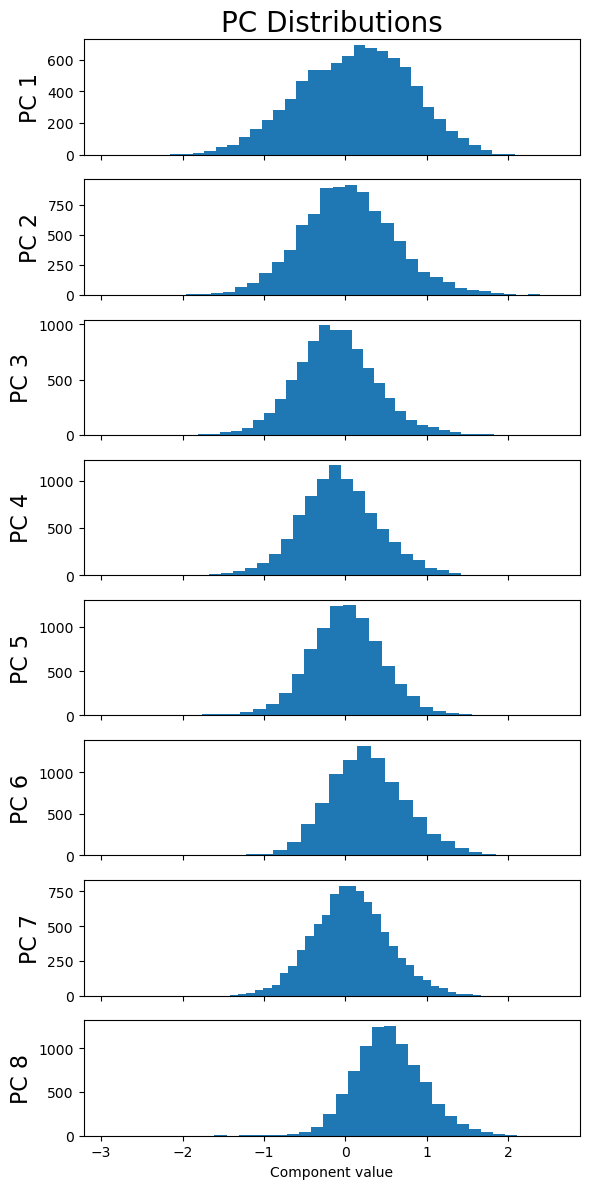

In [104]:
##################### PCA relevant figures #######################


########### plot distributions of PCs ###################
import matplotlib.pyplot as plt
fig, axes = plt.subplots(npcs, 1, figsize=(6,12), sharex=True)
for i, ax in enumerate(axes[:]):
    ax.hist(llsdf[pc_names].iloc[:,i].values, 30)
# for i, ax in enumerate(axes[:,1]):
#     ax.hist(nuc_weights[:,i], 30, (-2,2))
    
axes[0].set_title("PC Distributions", fontsize = 20)
# axes[0,1].set_title("Nucleus Distributions", fontsize = 20)
[ax.set_ylabel("PC %i"%(i+1), fontsize = 16) for i, ax in enumerate(axes[:])];
axes[7].set_xlabel("Component value")

plt.tight_layout()
plt.savefig(datadir.joinpath('PC distributions.png'), bbox_inches='tight')


# condf = pd.read_csv(confocaldir + 'All_Data_with_CGPS_bins.csv', index_col = 0)


# #pre-volume adjusted PCs
# origdf = smdf.merge(atidf.drop(columns=['image', 'cropx (pixels)',
#        'cropy (pixels)', 'cropz (pixels)']), left_on = 'cell', right_on = 'cell')
# origdf = origdf[origdf.Cell_Volume > 458]
# origdf = origdf[origdf.Cell_SurfaceArea < 1700]
# origdf = origdf[origdf.speed < 1.3]
# origdf = origdf[~origdf.cell.str.contains('20240528', na=False)].reset_index(drop=True)
# longcells = [i for i, x in origdf.groupby('CellID') if len(x)>360]
# origdf = origdf[origdf.CellID.isin(longcells)]
# # tranform the LLS data
# orig_coeff = origdf[[x for x in origdf.columns.to_list() if 'shcoeffs' in x]]
# orig_transform = pca.transform(orig_coeff)
# # Dataframe of transformed variable
# pc_names = [f"Cell_PC{c}" for c in range(1, 1 + npcs)]
# orig_trans = pd.DataFrame(data=orig_transform, columns=pc_names, index = orig_coeff.index)
# # orig_trans['Cell_Volume'] = origdf.Cell_Volume
# # for pcid, pc_name in enumerate(pc_names):
# #     pearson = np.corrcoef(orig_trans.Cell_Volume.values, orig_trans[pc_name].values)
# #     if pearson[0, 1] < 0:
# #         orig_trans[pc_name] *= -1
# #         pca.components_[pcid] *= -1
# # orig_trans = orig_trans.drop(columns = 'Cell_Volume')


# ########## plot distributions of PCs ###################
# import matplotlib.pyplot as plt
# fig, axes = plt.subplots(10, 1, figsize=(6,12), sharex=True)
# for i, ax in enumerate(axes[:]):
#     ax.hist(df_trans[pc_names].iloc[:,i].values, 30, density = True,alpha = 0.7, label = 'lls')
# #     ax.hist(orig_trans[pc_names].iloc[:,i].values, 30, density = True,alpha = 0.7, label = 'original')
#     ax.hist(condf[[x.split('Cell_')[-1] for x in pc_names]].iloc[:,i].values, 30, density = True,alpha = 0.7, label = 'confocal')
# axes[0].set_title("PC Distributions", fontsize = 20)
# # axes[0,1].set_title("Nucleus Distributions", fontsize = 20)
# [ax.set_ylabel("PC %i"%(i+1), fontsize = 16) for i, ax in enumerate(axes[:])];
# axes[-1].set_xlabel("Component value")
# ax.legend()
# plt.tight_layout()
# plt.savefig(savedir+ 'PC distributions.png', bbox_inches='tight')



In [114]:
############# BIN PCs TO USE IN CGPS ###################

#remove the "Cell_" from PCs
for x in llsdf.columns.to_list():
    if 'PC' in x:
        llsdf = llsdf.rename(columns = {x:x.replace('Cell_','')})

        
#### use the confocal bin size
bin_centers = pd.read_csv(confocaldir.joinpath('PC_bin_centers.csv'), index_col = 0)
nbins = len(bin_centers.iloc[:,0])
#check if lls data needs more bins, specifically for the relevant PCs
binmultis = []
for p in ['PC1','PC2','PC8']:
    #get bin centers
    binc = bin_centers[p].values
    #get bin width
    binw = np.diff(binc)[0]/2
    #get bin edges
    bine = np.unique([np.round(binc+bw, 6) for bw in [binw,-binw]])
    #get edge differences
    mindiff = llsdf[p].min() - bine[0]
    maxdiff = llsdf[p].max() - bine[-1]
    #get bin multiple difference
    maxval = max(maxdiff, abs(mindiff))
    binmultis.append(math.ceil(maxval/(binw*2)))

#calculate the increase in bins and new total bins
bincrease = max(binmultis)
llsnbins = nbins + 2*bincrease


pclist = [x for x in llsdf.columns.to_list() if 'PC' in x]
centers = []
for count, col in enumerate(pclist):
    binc = bin_centers[col].values
    binw = np.diff(binc)[0]/2
    #extend the bins to match the new bin number
    for n in range(int((llsnbins-len(binc))/2)):
        binc = np.insert(binc, 0, binc[0]-2*binw)
        binc = np.append(binc, binc[-1]+2*binw)
    # Force samples below/above -/+ 2std to fall into first/last bin
    bin_edges = np.unique([(round(b-binw,5), round(b+binw,5)) for b in binc])
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf
        
    # Aplly digitization
    llsdf[f'{col}bins'] = np.digitize(llsdf[col].values, bin_edges)

    #store the centers
    centers.append(binc)
    
#save the extended PC centers
pd.DataFrame(np.array(centers).T, columns = pclist).to_csv(datadir.joinpath('PC_bin_centers.csv'))
            

llsdf.to_csv(datadir.joinpath('All_Data_with_CGPS_bins.csv'))
print('Calculated combined PCs and binned PCs')

Calculated combined PCs and binned PCs
